# E73 · After LDA: newer topic models, problem by problem

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: the **Upworthy Research Archive** headline tests (as in E72: 4,468 tests with at least three vocabulary words, 652-word vocabulary, click-through rates) and the **UCI Online Retail** customers and products (as in E72 part H) |
| **You will learn** | What went wrong with LDA in E72 and which later models were designed for each problem · a common yardstick for topic models: **NPMI coherence**, **diversity**, **stability** across restarts (top-word overlap), and usefulness for a downstream prediction · short-text models: the **Dirichlet-multinomial mixture** (GSDMM) and the **biterm topic model** · **anchor-word** spectral recovery (deterministic, provable) and using it to start Gibbs chains · letting the data choose the number of topics: **learned asymmetric priors** and a truncated **hierarchical Dirichlet process** · a **neural topic model** (ProdLDA, amortised variational inference in JAX) and why evaluating one is hard · **supervised LDA**, where the outcome shapes the topics · **hierarchical Poisson factorisation** for purchase counts and recommendations · what embedding- and LLM-based topic models (BERTopic, TopicGPT) change, and what they do not |

## The setting

LDA (2003) is still the reference topic model, but E72 found five problems with it on real data.
Each has a family of later models built to address it:

| problem in E72 | why it happens | models built for it | part |
|---|---|---|---|
| headlines of ~9 words give fuzzy, unstable topics | each document says little about its own mixture | Dirichlet-multinomial mixture (Yin & Wang 2014), biterm topic model (Yan et al. 2013) | B |
| every restart finds different topics | the likelihood has many local modes | anchor-word / spectral methods (Arora et al. 2013) | C |
| no principled number of topics | $K$ is fixed in advance | learned asymmetric priors (Wallach, Mimno & McCallum 2009), the hierarchical Dirichlet process (Teh et al. 2006) | D |
| slow, awkward inference; only bag-of-words | Dirichlet geometry, per-document latent variables | neural topic models with amortised inference: ProdLDA (Srivastava & Sutton 2017), the embedded topic model (Dieng, Ruiz & Blei 2020) | E |
| topics found without the outcome, then used to predict it | two-stage analysis | supervised LDA (Blei & McAuliffe 2007) | F |
| counts of purchases, not bags of words; recommendations | the multinomial fixes each document's length | Poisson factorisation (Gopalan, Hofman & Blei 2015) | G |

Every model gets the **same yardsticks**, on the same headline corpus and with six topics where
the model allows it:

* **coherence (NPMI)**: for each topic's top 10 words, the average normalised pointwise mutual
  information of every pair across the corpus's documents (Lau, Newman & Baldwin 2014): 1 = the
  words always occur together, 0 = independent, -1 = never together. It tracks human judgements
  of topic quality moderately well.
* **diversity**: the share of distinct words among all topics' top 25 (1 = no word shared).
* **stability**: fit from four random starts, match each topic of the first run to one topic of
  every other run (Hungarian algorithm on top-word overlap), and report the **Jaccard overlap**
  of their top-10 word sets (1 = identical, 0 = no word in common): the worst over runs, per topic.
  (Cosine similarity of word distributions, used in E72, is fooled by near-uniform topics: while
  preparing this notebook it gave the neural model of part E a "stability" of 0.99 for topics that
  shared almost no top words.)
* **usefulness**: E72's five-fold cross-validated $R^2$ for a story's month-adjusted
  click-through, from its topic mixture.

None of these methods is in the project's environment as a package, so each is written out
here in a few dozen lines of NumPy, Numba or JAX - which is also the clearest way to see what
each one changes.

In [1]:
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
import re
from collections import Counter
from scipy.optimize import linear_sum_assignment, nnls
from scipy.special import digamma

from pymc_challenges import data

RANDOM_SEED = 73
az.style.use("arviz-variat")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]   # fixed categorical order
INK, MUTED = "#0b0b0b", "#8a8984"

## A. The corpus, the yardsticks and the baseline

The preparation is E72's, unchanged: one document per test (all its distinct headlines), stopwords
removed, plurals folded, words in at least 20 and at most 10% of tests.

In [2]:
data.describe("upworthy_exploratory")
uw = data.load("upworthy_exploratory")
STOP = set("""a about above after again against all am an and any are aren't as at be because been before
being below between both but by can can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her here here's
hers herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me
more most mustn't my myself no nor not of off on once only or other ought our ours ourselves out over own same
shan't she she'd she'll she's should shouldn't so some such than that that's the their theirs them themselves
then there there's these they they'd they'll they're they've this those through to too under until up very
was wasn't we we'd we'll we're we've were weren't what what's when when's where where's which while who who's
whom why why's with won't would wouldn't you you'd you'll you're you've your yours yourself yourselves just
like get gets got one two really thing things way ever even also make makes made know see go going goes say
says said will new something every much many want wants yes""".split())


def tokens(headline):
    words = re.findall(r"[a-z][a-z']+", headline.lower().replace("’", "'"))
    return [w for w in words if w not in STOP and len(w) > 2]


heads = uw.drop_duplicates(["test_id", "headline"])
docs = heads.groupby("test_id")["headline"].apply(lambda h: sum((tokens(x) for x in h), []))
doc_freq = Counter(w for d in docs for w in set(d))
fold = {w: w[:-1] for w in doc_freq if w.endswith("s") and doc_freq.get(w[:-1], 0) >= 20}
docs = docs.map(lambda d: [fold.get(w, w) for w in d])
doc_freq = Counter(w for d in docs for w in set(d))
vocab = np.array(sorted(w for w, c in doc_freq.items() if 20 <= c <= 0.1 * len(docs)))
w_index = {w: i for i, w in enumerate(vocab)}
X_all = np.zeros((len(docs), len(vocab)), dtype=np.int64)
for d, ws in enumerate(docs):
    for w in ws:
        if w in w_index:
            X_all[d, w_index[w]] += 1
keep = X_all.sum(1) >= 3
X_txt, test_ids = X_all[keep], docs.index.to_numpy()[keep]
@numba.njit
def _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, n_sweeps, seed):
    np.random.seed(seed)
    K, V = nkw.shape
    cum = np.empty(K)
    for _ in range(n_sweeps):
        for i in range(doc.shape[0]):
            d, w, k = doc[i], word[i], z[i]
            ndk[d, k] -= 1
            nkw[k, w] -= 1
            nk[k] -= 1
            total = 0.0
            for j in range(K):
                total += (ndk[d, j] + alpha) * (nkw[j, w] + beta) / (nk[j] + V * beta)
                cum[j] = total
            u = np.random.random() * total
            k = 0
            while cum[k] < u:
                k += 1
            z[i] = k
            ndk[d, k] += 1
            nkw[k, w] += 1
            nk[k] += 1


def lda_gibbs(X, K, alpha=0.1, beta=0.05, burn=2000, draws=40, thin=10, seed=0):
    """Collapsed Gibbs LDA on a document x word count matrix.

    Returns posterior draws of phi (draw, topic, word) and theta (draw, doc, topic), and the
    log-likelihood of the tokens at each saved sweep.
    """
    g = np.random.default_rng(seed)
    d_i, w_i = np.nonzero(X)
    n = X[d_i, w_i]
    doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    z = g.integers(K, size=doc.size)
    D, V = X.shape
    ndk, nkw = np.zeros((D, K), np.int64), np.zeros((K, V), np.int64)
    np.add.at(ndk, (doc, z), 1)
    np.add.at(nkw, (z, word), 1)
    nk = nkw.sum(1)
    _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, burn, seed)
    phis, thetas, lls = [], [], []
    for s in range(draws):
        _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, thin, seed + 1 + s)
        phi_s = g.gamma(nkw + beta)
        theta_s = g.gamma(ndk + alpha)
        phis.append(phi_s / phi_s.sum(1, keepdims=True))
        thetas.append(theta_s / theta_s.sum(1, keepdims=True))
        lls.append(np.sum(X * np.log(thetas[-1] @ phis[-1])))
    return np.array(phis), np.array(thetas), np.array(lls)


@numba.njit
def _foldin_sweeps(doc, word, z, ndk, phi, alpha, n_sweeps, seed):
    np.random.seed(seed)
    K = phi.shape[0]
    cum = np.empty(K)
    for _ in range(n_sweeps):
        for i in range(doc.shape[0]):
            d, w, k = doc[i], word[i], z[i]
            ndk[d, k] -= 1
            total = 0.0
            for j in range(K):
                total += (ndk[d, j] + alpha) * phi[j, w]
                cum[j] = total
            u = np.random.random() * total
            k = 0
            while cum[k] < u:
                k += 1
            z[i] = k
            ndk[d, k] += 1


tests = uw.groupby("test_id").agg(clicks=("clicks", "sum"), impressions=("impressions", "sum"),
                                  week=("test_week", "first")).loc[test_ids]
logit_ctr = np.log((tests["clicks"] + 0.5) / (tests["impressions"] - tests["clicks"] + 0.5)).to_numpy()
year, wk = tests["week"].to_numpy() // 100, tests["week"].to_numpy() % 100
month = (year - year.min()) * 12 + np.minimum((wk - 1) * 12 // 52, 11)
month_idx, month_codes = pd.factorize(month, sort=True)
y_rel = logit_ctr - pd.Series(logit_ctr).groupby(month_idx).transform("mean").to_numpy()
cv_fold = np.random.default_rng(2).integers(5, size=len(y_rel))

def cv_r2(F, lam=1.0):
    pred = np.zeros_like(y_rel)
    for f in range(5):
        tr = cv_fold != f
        A = np.c_[np.ones(tr.sum()), F[tr]]
        b = np.linalg.solve(A.T @ A + lam * np.eye(A.shape[1]), A.T @ y_rel[tr])
        pred[~tr] = np.c_[np.ones((~tr).sum()), F[~tr]] @ b
    return 1 - np.mean((y_rel - pred) ** 2) / np.var(y_rel)

def cosine(a, b):
    return np.sum(a * b, -1) / np.linalg.norm(a, axis=-1) / np.linalg.norm(b, axis=-1)

def stability(phis):
    """phis: list of (K, V) topic matrices from restarts. Per topic of run 0: min cosine to its match."""
    ref = phis[0]; sims = []
    for other in phis[1:]:
        perm = linear_sum_assignment(-cosine(ref[:, None], other[None]))[1]
        sims.append(cosine(ref, other[perm]))
    return np.min(sims, 0)

Xb = (X_txt > 0).astype(float)
n_docs = len(Xb)
doc_freq_w = Xb.sum(0)
co_doc = Xb.T @ Xb
def npmi(phi, top=10):
    """Mean NPMI of top-word pairs (document co-occurrence in the corpus), per topic."""
    out = []
    for k in range(len(phi)):
        t = np.argsort(-phi[k])[:top]; vals = []
        for i in range(top):
            for j in range(i + 1, top):
                pij = co_doc[t[i], t[j]] / n_docs
                pi, pj = doc_freq_w[t[i]] / n_docs, doc_freq_w[t[j]] / n_docs
                vals.append(-1.0 if pij == 0 else np.log(pij / (pi * pj)) / -np.log(pij))
        out.append(np.mean(vals))
    return np.array(out)

def diversity(phi, top=25):
    tops = np.concatenate([np.argsort(-p)[:top] for p in phi])
    return len(np.unique(tops)) / len(tops)

def top_words(phi, n=6):
    return [" / ".join(vocab[np.argsort(-p)[:n]]) for p in phi]

def top_sets(phi, n=10):
    return [set(np.argsort(-p)[:n]) for p in phi]

def stability_jaccard(phis, n=10):
    """Per topic of run 0: the smallest (over other runs) Jaccard overlap of top-n words with its best match."""
    ref = top_sets(phis[0], n); out = []
    for other in phis[1:]:
        o = top_sets(other, n)
        J = np.array([[len(a & b) / len(a | b) for b in o] for a in ref])
        perm = linear_sum_assignment(-J)[1]
        out.append(J[np.arange(len(ref)), perm])
    return np.min(out, 0)
print(f"{len(X_txt):,} tests x {len(vocab)} words, {X_txt.sum():,} tokens (median {np.median(X_txt.sum(1)):.0f} per test)")

upworthy_exploratory: Exploratory sample of Upworthy's headline A/B tests, Jan 2013 - Apr 2015: 4,873 tests, 22,666 packages (arms; 2-14 per test, mostly 4-6), one row per package: test_id (clickability_test_id), test_created (date of the test's first package), test_week (YYYYWW), arm (0.. within test, by creation time), content_id (arms of one test with the same id are identical in headline, image, excerpt, lede, share text and square image: natural A/A arms), headline, eyecatcher_id (image), impressions, clicks, significance (Upworthy's dashboard number), first_place, winner (editor's declared winner).
  source: Matias, Munger, Aubin Le Quere & Ebersole (2021), The Upworthy Research Archive, a time series of 32,487 experiments in U.S. media, Scientific Data 8:195 (doi:10.1038/s41597-021-00934-7); OSF project jd64p (CC BY 4.0), file upworthy-archive-exploratory-packages-03.12.2020.csv (the URL). TRIMMED: kept the columns below, dropped excerpt/lede/share text/image URL/slug, added arm

4,468 tests x 652 words, 52,590 tokens (median 9 per test)


In [3]:
scoreboard = []


def score(name, phis, thetas=None, seconds=np.nan):
    """Add a row to the scoreboard: phis = topic-word matrices from restarts; thetas = mixtures per restart."""
    stab = stability_jaccard(phis)
    row = {"model": name, "coherence (NPMI)": npmi(phis[0]).mean(), "diversity": diversity(phis[0]),
           "stability, worst topic": stab.min(), "stability, median topic": np.median(stab),
           "click-through CV R2": np.mean([cv_r2(t) for t in thetas]) if thetas is not None else np.nan,
           "seconds per fit": seconds}
    scoreboard.append(row)
    return pd.Series(row).drop("model")


def show_topics(phi, n=7, title=None):
    if title:
        print(title)
    for k, words in enumerate(top_words(phi, n)):
        print(f"   {k}: {words}")


t0 = time.perf_counter()
lda_runs = [lda_gibbs(X_txt, 6, seed=s, draws=20) for s in range(4)]
secs = (time.perf_counter() - t0) / 4
lda_phis = [r[0].mean(0) for r in lda_runs]
print(score("LDA (collapsed Gibbs), 6 topics", lda_phis, [r[1].mean(0) for r in lda_runs], secs).round(3))
show_topics(lda_phis[0], title="LDA, first run:")
print("per-topic stability (Jaccard of top 10):", np.round(stability_jaccard(lda_phis), 2))

coherence (NPMI)           0.081
diversity                  0.727
stability, worst topic     0.053
stability, median topic     0.25
click-through CV R2        0.105
seconds per fit            2.519
dtype: object
LDA, first run:
   0: world / video / change / think / life / look / food
   1: kid / school / parent / love / word / teacher / world
   2: year / girl / old / gay / ask / question / little
   3: video / never / minute / first / second / guy / watch
   4: state / reason / think / time / america / country / job
   5: women / guy / men / woman / think / black / talk
per-topic stability (Jaccard of top 10): [0.33 0.18 0.25 0.25 0.05 0.33]


The baseline in numbers: moderately coherent topics (NPMI about 0.08), and poor stability: the
best-matched topic of another run shares on average only a few of its ten top words.

## B. Short texts: one topic per document, or topics from word pairs

LDA gives every headline set its own mixture, estimated from nine words. Two models for short
texts change that assumption.

**The Dirichlet-multinomial mixture** (DMM; Yin & Wang's collapsed Gibbs sampler is known as
GSDMM) says each short document is about **one** topic: $z_d \sim \text{Categorical}(\boldsymbol\pi)$,
and all its words come from $\boldsymbol\phi_{z_d}$. It is a mixture model (clustering), not a
mixed-membership one. Its collapsed Gibbs sampler moves a whole document at a time:

$$P(z_d = k \mid \cdot) \propto (m_k + \alpha)\,
\frac{\prod_{w \in d}\prod_{j=1}^{n_{dw}} (n_{kw} + \beta + j - 1)}{\prod_{i=1}^{N_d} (n_k + V\beta + i - 1)}.$$

**The biterm topic model** (BTM) instead learns topics from **word pairs**: every unordered pair
of words in the same short document is a *biterm*, each biterm has one topic drawn from a single
corpus-wide topic distribution, and both its words come from that topic. Co-occurrence is
pooled over the whole corpus, so short documents no longer have to estimate their own
mixtures; a document's mixture is recovered afterwards as the average of its biterms' topic
probabilities.

In [4]:
@numba.njit
def _dmm_sweeps(doc_ptr, word, z, m, nkw, nk, alpha, beta, n_sweeps, seed):
    np.random.seed(seed)
    K, V = nkw.shape
    D = len(z)
    logp = np.empty(K)
    for _ in range(n_sweeps):
        for d in range(D):
            a, b = doc_ptr[d], doc_ptr[d + 1]
            k = z[d]
            m[k] -= 1
            for i in range(a, b):
                nkw[k, word[i]] -= 1
            nk[k] -= b - a
            for j in range(K):
                lp = np.log(m[j] + alpha)
                # tokens of the document are sorted by word, so repeated words are adjacent
                rep = 0
                for i in range(a, b):
                    if i > a and word[i] == word[i - 1]:
                        rep += 1
                    else:
                        rep = 0
                    lp += np.log(nkw[j, word[i]] + beta + rep)
                for i in range(b - a):
                    lp -= np.log(nk[j] + V * beta + i)
                logp[j] = lp
            mx = logp.max()
            tot = 0.0
            for j in range(K):
                logp[j] = np.exp(logp[j] - mx)
                tot += logp[j]
            u = np.random.random() * tot
            k = 0
            acc = logp[0]
            while acc < u:
                k += 1
                acc += logp[k]
            z[d] = k
            m[k] += 1
            for i in range(a, b):
                nkw[k, word[i]] += 1
            nk[k] += b - a

def dmm_gibbs(X, K, alpha=0.1, beta=0.05, burn=300, draws=20, thin=10, seed=0):
    g = np.random.default_rng(seed)
    D, V = X.shape
    d_i, w_i = np.nonzero(X); n = X[d_i, w_i]
    word = np.repeat(w_i, n); doc_of = np.repeat(d_i, n)
    doc_ptr = np.r_[0, np.cumsum(X.sum(1))]
    z = g.integers(K, size=D)
    m = np.bincount(z, minlength=K).astype(np.int64)
    nkw = np.zeros((K, V), np.int64); np.add.at(nkw, (z[doc_of], word), 1); nk = nkw.sum(1)
    _dmm_sweeps(doc_ptr, word, z, m, nkw, nk, alpha, beta, burn, seed)
    phis, resp = [], np.zeros((D, K))
    for s in range(draws):
        _dmm_sweeps(doc_ptr, word, z, m, nkw, nk, alpha, beta, thin, seed + 1 + s)
        ph = g.gamma(nkw + beta); phis.append(ph / ph.sum(1, keepdims=True))
        # soft cluster membership given the topics: p(z_d = k | x_d)
        lr = np.log(m + alpha)[None] + X @ np.log(phis[-1]).T
        lr = np.exp(lr - lr.max(1, keepdims=True)); resp += lr / lr.sum(1, keepdims=True)
    return np.array(phis), resp / draws, m

@numba.njit
def _btm_sweeps(w1, w2, z, nk, nkw, alpha, beta, n_sweeps, seed):
    np.random.seed(seed)
    K, V = nkw.shape
    cum = np.empty(K)
    for _ in range(n_sweeps):
        for b in range(len(z)):
            k = z[b]; i, j = w1[b], w2[b]
            nk[k] -= 1; nkw[k, i] -= 1; nkw[k, j] -= 1
            tot = 0.0
            for t in range(K):
                nw = 2.0 * nk[t]
                tot += (nk[t] + alpha) * (nkw[t, i] + beta) * (nkw[t, j] + beta) / ((nw + V * beta) * (nw + 1 + V * beta))
                cum[t] = tot
            u = np.random.random() * tot
            k = 0
            while cum[k] < u:
                k += 1
            z[b] = k; nk[k] += 1; nkw[k, i] += 1; nkw[k, j] += 1

def biterms(X):
    d_list, a_list, b_list = [], [], []
    for d in range(len(X)):
        toks = np.repeat(np.arange(X.shape[1]), X[d])
        ii, jj = np.triu_indices(len(toks), 1)
        d_list.append(np.full(len(ii), d)); a_list.append(toks[ii]); b_list.append(toks[jj])
    return np.concatenate(d_list), np.concatenate(a_list), np.concatenate(b_list)

def btm_gibbs(X, K, alpha=None, beta=0.01, burn=300, draws=20, thin=10, seed=0):
    g = np.random.default_rng(seed)
    bd, w1, w2 = biterms(X)
    alpha = 50 / K if alpha is None else alpha
    V = X.shape[1]
    z = g.integers(K, size=len(w1)); nk = np.bincount(z, minlength=K).astype(np.int64)
    nkw = np.zeros((K, V), np.int64); np.add.at(nkw, (z, w1), 1); np.add.at(nkw, (z, w2), 1)
    _btm_sweeps(w1, w2, z, nk, nkw, alpha, beta, burn, seed)
    phis, thetas = [], np.zeros((len(X), K))
    for s in range(draws):
        _btm_sweeps(w1, w2, z, nk, nkw, alpha, beta, thin, seed + 1 + s)
        ph = (nkw + beta) / (2 * nk[:, None] + V * beta); phis.append(ph)
        pz = (nk + alpha) / (nk.sum() + K * alpha)
        pb = pz[None] * ph[:, w1].T * ph[:, w2].T; pb /= pb.sum(1, keepdims=True)   # p(z | biterm)
        th = np.zeros((len(X), K)); np.add.at(th, bd, pb)
        nb = np.bincount(bd, minlength=len(X))[:, None]
        thetas += np.where(nb > 0, th / np.maximum(nb, 1), pz[None])
    return np.array(phis), thetas / draws, len(w1)

t0 = time.perf_counter()
dmm_runs = [dmm_gibbs(X_txt, 6, seed=s) for s in range(4)]
secs = (time.perf_counter() - t0) / 4
dmm_phis = [r[0].mean(0) for r in dmm_runs]
print(score("DMM (GSDMM), 6 clusters", dmm_phis, [r[1] for r in dmm_runs], secs).round(3))
print("documents per cluster, first run:", dmm_runs[0][2])
show_topics(dmm_phis[0], title="DMM clusters:")

t0 = time.perf_counter()
btm_runs = [btm_gibbs(X_txt, 6, seed=s) for s in range(4)]
secs = (time.perf_counter() - t0) / 4
btm_phis = [r[0].mean(0) for r in btm_runs]
print(f"\n{btm_runs[0][2]:,} biterms")
print(score("Biterm topic model, 6 topics", btm_phis, [r[1] for r in btm_runs], secs).round(3))
show_topics(btm_phis[0], title="BTM topics:")

coherence (NPMI)          -0.021
diversity                  0.733
stability, worst topic     0.053
stability, median topic    0.333
click-through CV R2        0.097
seconds per fit            1.296
dtype: object
documents per cluster, first run: [2474  252  412 1132   96  102]
DMM clusters:
   0: kid / world / now / time / year / think / look
   1: fact / oliver / jon / john / senator / wage / president
   2: year / old / girl / gay / kid / boy / question
   3: women / guy / men / woman / think / video / black
   4: watch / reason / girl / full / heard / room / good
   5: guy / think / kid / big / argument / simple / science



438,798 biterms
coherence (NPMI)          -0.004
diversity                  0.713
stability, worst topic     0.176
stability, median topic    0.292
click-through CV R2        0.097
seconds per fit            5.746
dtype: object
BTM topics:
   0: guy / video / think / science / watch / kid / talk
   1: year / girl / kid / old / little / word / watch
   2: women / woman / men / think / word / man / never
   3: kid / now / world / help / live / look / time
   4: john / oliver / fact / question / epic / ask / answer
   5: argument / wage / minimum / map / commercial / state / gay


Can the one-topic-per-document assumption find the "right" number of clusters by itself? GSDMM is
usually run with many more clusters than needed, on the understanding that empty ones die out.

DMM with 40 clusters (12 s): 40 non-empty


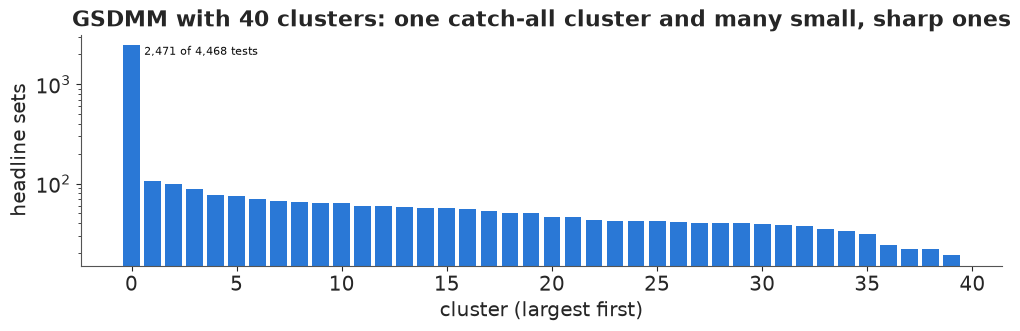

In [5]:
t0 = time.perf_counter()
_, _, sizes40 = dmm_gibbs(X_txt, 40, seed=0, burn=500)
print(f"DMM with 40 clusters ({time.perf_counter() - t0:.0f} s): {np.sum(sizes40 > 0)} non-empty")
fig, ax = plt.subplots(figsize=(10, 3.2))
order40 = np.argsort(-sizes40)
ax.bar(range(40), sizes40[order40], color=SERIES[0])
ax.set(xlabel="cluster (largest first)", ylabel="headline sets", yscale="log",
       title="GSDMM with 40 clusters: one catch-all cluster and many small, sharp ones")
ax.text(0.6, sizes40.max() * 0.8, f"{sizes40.max():,} of {len(X_txt):,} tests", fontsize=8, color=INK);

Neither short-text model fixes the headlines. The DMM puts 2,474 of the 4,468 stories into one
catch-all cluster ("kid / world / now / time"): with one topic per document, a story that fits
nowhere in particular goes where the counts are largest ($m_k + \alpha$ rewards big clusters), and
with 40 clusters the catch-all is still there (2,471 stories). The other clusters are small and
sharp - the John Oliver and Jon Stewart segments ("fact / oliver / jon / john / senator") are a
cluster of their own. The biterm model finds the same sharp stories (John Oliver; the minimum-wage
argument) and has the best worst-topic stability of the sampled models (0.18 against LDA's 0.05),
but its large topics are generic words, so its coherence is lower (NPMI about 0 against 0.08),
and neither predicts click-through better than LDA (0.097 against 0.105).

These models were designed for tweets and search snippets that are each about one thing in
specific words. Upworthy's headline sets are about one story, but told in a small generic
"clickbait" vocabulary - the problem is the generic words as much as the length.

## C. Local modes: a deterministic answer, and a better start

Gibbs samplers for LDA wander between local modes; every restart gives different topics. The
**anchor-word** algorithm (Arora et al. 2013) avoids the likelihood altogether. It assumes each
topic has an *anchor* word that appears in that topic only. Then every word's co-occurrence
profile is a convex combination of the anchors' profiles, the anchors are the corners of the
convex hull of all profiles, and topics follow by linear algebra:

1. estimate the word-by-word co-occurrence matrix $Q$ from the documents;
2. find $K$ anchor words greedily - the word farthest from the origin, then repeatedly the word
   farthest from the span of those already chosen (restricted to words in at least 50 tests, as
   rare words make noisy corners);
3. write every word's conditional co-occurrence row as a convex combination of the anchors' rows
   (non-negative least squares), which gives $p(\text{topic} \mid \text{word})$, and invert with
   Bayes' rule to get the topics.

The answer is deterministic and, for enough data from a model with anchors, provably correct.

In [6]:
def cooccurrence(X):
    """Arora et al. (2013) unbiased word co-occurrence estimate from documents with >= 2 tokens."""
    X = X[X.sum(1) >= 2].astype(float)
    n = X.sum(1)
    w = 1 / (n * (n - 1))
    Q = (X * w[:, None]).T @ X - np.diag((X * w[:, None]).sum(0))
    return Q / Q.sum()

def find_anchors(Qbar, K, candidates):
    """Greedy farthest-point anchors in the row space of Qbar (Gram-Schmidt), among candidate words."""
    rows = Qbar[candidates].copy()
    anchors = [int(np.argmax(np.linalg.norm(rows, axis=1)))]
    basis = []
    for _ in range(K - 1):
        v = rows[anchors[-1]] - (rows[anchors[0]] if len(anchors) > 1 else 0)
        if len(anchors) == 1:
            # second anchor: farthest from the first
            d = np.linalg.norm(rows - rows[anchors[0]], axis=1)
            anchors.append(int(np.argmax(d)))
            b = rows[anchors[1]] - rows[anchors[0]]
            basis.append(b / np.linalg.norm(b))
            continue
        resid = rows - rows[anchors[0]]
        for b in basis:
            resid = resid - np.outer(resid @ b, b)
        anchors.append(int(np.argmax(np.linalg.norm(resid, axis=1))))
        b = resid[anchors[-1]] / np.linalg.norm(resid[anchors[-1]])
        basis.append(b)
    return np.array(candidates)[anchors]

def recover(Q, anchors, lam=1e3):
    """RecoverL2: each word's conditional row as a convex combination of the anchor rows."""
    p_w = Q.sum(1)
    Qbar = Q / p_w[:, None]
    A_rows = Qbar[anchors]                          # K x V
    M = np.vstack([A_rows.T, np.sqrt(lam) * np.ones(len(anchors))])
    C = np.array([nnls(M, np.r_[Qbar[i], np.sqrt(lam)])[0] for i in range(len(Q))])
    C = C / C.sum(1, keepdims=True)
    A = C * p_w[:, None]                            # p(word, topic) up to normalisation
    return (A / A.sum(0)).T                         # K x V

t0 = time.perf_counter()
Q = cooccurrence(X_txt)
Qbar = Q / Q.sum(1, keepdims=True)
anchor_words = find_anchors(Qbar, 6, np.flatnonzero(doc_freq_w >= 50))
phi_anchor = recover(Q, anchor_words)
secs = time.perf_counter() - t0
print(f"anchor words: {', '.join(vocab[anchor_words])}  ({secs:.2f} s)")
d_i, w_i = np.nonzero(X_txt)
tok_doc, tok_word = np.repeat(d_i, X_txt[d_i, w_i]), np.repeat(w_i, X_txt[d_i, w_i])
theta_anchor = np.zeros((len(X_txt), 6))
for s in range(5):
    z0 = np.random.default_rng(s).integers(6, size=tok_doc.size)
    ndk0 = np.zeros((len(X_txt), 6), np.int64)
    np.add.at(ndk0, (tok_doc, z0), 1)
    _foldin_sweeps(tok_doc, tok_word, z0, ndk0, np.clip(phi_anchor, 1e-9, None), 0.1, 50, s)
    theta_anchor += (ndk0 + 0.1) / (ndk0.sum(1, keepdims=True) + 0.6) / 5
print(score("Anchor words (spectral)", [phi_anchor, phi_anchor], [theta_anchor], secs).round(3))
show_topics(phi_anchor, title="Anchor-word topics:")

anchor words: ago, straight, scary, try, kinda, student  (0.04 s)


coherence (NPMI)           0.029
diversity                  0.333
stability, worst topic       1.0
stability, median topic      1.0
click-through CV R2        0.012
seconds per fit            0.045
dtype: object
Anchor-word topics:
   0: old / year / ago / time / now / kid / look
   1: gay / guy / think / kid / straight / girl / watch
   2: women / kid / scary / real / guy / time / think
   3: happen / kid / women / try / guy / time / think
   4: women / think / guy / kid / look / year / world
   5: kid / think / women / student / guy / watch / time


Deterministic, instant - and on this corpus, poor: generic words ("kid", "women", "guy", "think")
top almost every topic (diversity about a third), and the anchors are odd choices. The
guarantees need many documents and co-occurrence estimates with little noise; 4,468 headline sets
of nine words are neither. Still, a deterministic answer is a good *starting point*: give every
Gibbs chain the anchor topics as its initial state (token topics drawn by fold-in under them) and
let it sample from there.

In [7]:
def gibbs_from(X, phi0, K, alpha=0.1, beta=0.05, burn=2000, draws=20, thin=10, seed=0):
    """LDA collapsed Gibbs whose token topics start from a fold-in under phi0 (not at random)."""
    g = np.random.default_rng(seed)
    d_i, w_i = np.nonzero(X); n = X[d_i, w_i]; doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    D, V = X.shape
    z = g.integers(K, size=doc.size); ndk = np.zeros((D, K), np.int64); np.add.at(ndk, (doc, z), 1)
    _foldin_sweeps(doc, word, z, ndk, np.clip(phi0, 1e-9, None), alpha, 30, seed)
    nkw = np.zeros((K, V), np.int64); np.add.at(nkw, (z, word), 1); nk = nkw.sum(1)
    _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, burn, seed + 7)
    phis, thetas = [], []
    for s in range(draws):
        _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, thin, seed + 100 + s)
        phis.append((nkw + beta) / (nk[:, None] + V * beta)); thetas.append((ndk + alpha) / (ndk.sum(1, keepdims=True) + K * alpha))
    return np.array(phis), np.array(thetas)

t0 = time.perf_counter()
anchored = [gibbs_from(X_txt, phi_anchor, 6, seed=s) for s in range(4)]
secs = (time.perf_counter() - t0) / 4
anch_phis = [r[0].mean(0) for r in anchored]
print(score("LDA, Gibbs started from anchors", anch_phis, [r[1].mean(0) for r in anchored], secs).round(3))
print("per-topic stability (Jaccard):", np.round(stability_jaccard(anch_phis), 2))


def token_loglik(phi, theta):
    return np.sum(X_txt * np.log(theta @ phi))


ll_random = [token_loglik(r[0].mean(0), r[1].mean(0)) for r in lda_runs]
ll_anchor = [token_loglik(r[0].mean(0), r[1].mean(0)) for r in anchored]
print("token log-likelihood, random starts: ", np.round(ll_random))
print("token log-likelihood, anchor starts: ", np.round(ll_anchor))
show_topics(anch_phis[0], title="Anchor-started LDA, first run:")

coherence (NPMI)           0.083
diversity                  0.713
stability, worst topic     0.111
stability, median topic    0.292
click-through CV R2        0.101
seconds per fit            2.247
dtype: object
per-topic stability (Jaccard): [0.43 0.25 0.33 0.33 0.11 0.18]
token log-likelihood, random starts:  [-298903. -298314. -298917. -298489.]
token log-likelihood, anchor starts:  [-298793. -298801. -298772. -298685.]
Anchor-started LDA, first run:
   0: year / girl / old / little / life / kid / world
   1: gay / question / ask / asked / answer / watch / news
   2: video / guy / minute / science / second / real / fact
   3: women / woman / men / think / word / black / tell
   4: live / world / food / now / work / time / right
   5: kid / school / parent / teacher / word / think / tell


Starting every chain from the anchor topics keeps LDA's coherence and predictive value, but
barely improves stability (median top-word overlap 0.29 against 0.25), and the chains end at
likelihoods like those of random starts (about -298,700 to -298,800 against -298,300 to
-298,900). A shared start makes runs *reproducible*, not *right*: the chains still drift to
different, equally good ways of cutting up the vocabulary. The anchor method's natural setting is
a very large corpus, where co-occurrence is estimated precisely and where its speed (0.04 s here,
against seconds per Gibbs chain) matters most.

## D. How many topics? Let the prior decide

E72 chose $K$ by what the topics were for. Two ways to let the model choose:

* **Learned asymmetric priors** (Wallach, Mimno & McCallum 2009): start with many topics and a
  separate $\alpha_k$ for each, and update the $\alpha_k$ from the data (Minka's fixed-point
  iteration for a Dirichlet, every 20 sweeps). A topic the data do not need should get a tiny
  $\alpha_k$ and fade.
* **The hierarchical Dirichlet process** (HDP; Teh, Jordan, Beal & Blei 2006): a corpus-wide set
  of topic weights $\boldsymbol\beta$ drawn from a Dirichlet process, and each document's mixture
  from $\text{Dirichlet}(\alpha\boldsymbol\beta)$ - infinitely many topics, of which the data use
  a finite number. We use the **weak-limit** approximation (a truncation at $K_\max$ topics with
  $\boldsymbol\beta \sim \text{Dirichlet}(\gamma/K_\max)$), sampling $\boldsymbol\beta$ from the
  "table counts" of the Chinese restaurant franchise (an Antoniak draw per document and topic).
  If $K_\max$ is large enough, the answer should not depend on it.

four fits: 29 s
LDA, 30 topics, symmetric prior            topics with > 1% of tokens:  30;  largest topic: 4%
LDA, 30 topics, learned asymmetric prior   topics with > 1% of tokens:  30;  largest topic: 11%
HDP, truncated at 40                       topics with > 1% of tokens:  40;  largest topic: 10%
HDP, truncated at 100                      topics with > 1% of tokens:  41;  largest topic: 3%
click-through CV R2: HDP-40 0.128 | HDP-100 0.124 | asymmetric-30 0.108 | symmetric-30 0.096


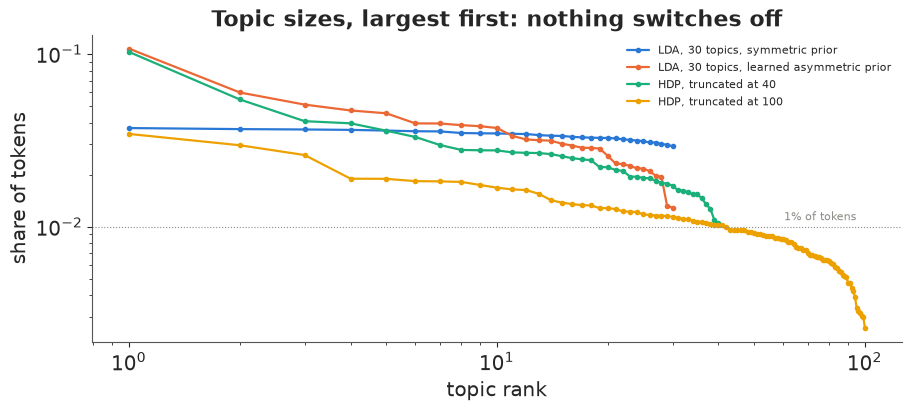

In [8]:
@numba.njit
def _gibbs_sweeps_asym(doc, word, z, ndk, nkw, nk, alpha, beta, n_sweeps, seed):
    np.random.seed(seed)
    K, V = nkw.shape
    cum = np.empty(K)
    for _ in range(n_sweeps):
        for i in range(doc.shape[0]):
            d, w, k = doc[i], word[i], z[i]
            ndk[d, k] -= 1; nkw[k, w] -= 1; nk[k] -= 1
            total = 0.0
            for j in range(K):
                total += (ndk[d, j] + alpha[j]) * (nkw[j, w] + beta) / (nk[j] + V * beta)
                cum[j] = total
            u = np.random.random() * total
            k = 0
            while cum[k] < u:
                k += 1
            z[i] = k; ndk[d, k] += 1; nkw[k, w] += 1; nk[k] += 1

def lda_asym(X, K, alpha0=0.1, beta=0.05, burn=2000, every=20, draws=20, thin=10, seed=0):
    g = np.random.default_rng(seed)
    d_i, w_i = np.nonzero(X); n = X[d_i, w_i]; doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    D, V = X.shape
    z = g.integers(K, size=doc.size)
    ndk = np.zeros((D, K), np.int64); nkw = np.zeros((K, V), np.int64)
    np.add.at(ndk, (doc, z), 1); np.add.at(nkw, (z, word), 1); nk = nkw.sum(1)
    alpha = np.full(K, alpha0); nd = ndk.sum(1); path = []
    for it in range(burn // every):
        _gibbs_sweeps_asym(doc, word, z, ndk, nkw, nk, alpha, beta, every, seed + it)
        if it >= 5:   # Minka's fixed-point update of an asymmetric Dirichlet (Wallach, Mimno & McCallum 2009)
            for _ in range(5):
                num = (digamma(ndk + alpha) - digamma(alpha)).sum(0)
                den = (digamma(nd + alpha.sum()) - digamma(alpha.sum())).sum()
                alpha = np.maximum(alpha * num / den, 1e-4)
        path.append(alpha.copy())
    phis, thetas = [], []
    for s in range(draws):
        _gibbs_sweeps_asym(doc, word, z, ndk, nkw, nk, alpha, beta, thin, seed + 10_000 + s)
        phis.append((nkw + beta) / (nk[:, None] + V * beta)); thetas.append((ndk + alpha) / (nd[:, None] + alpha.sum()))
    return np.array(phis), np.array(thetas), np.array(path), nk

@numba.njit
def _table_counts(ndk, ab, seed):
    """Antoniak draw: tables m_dk for n_dk customers in a CRP with concentration alpha * beta_k."""
    np.random.seed(seed)
    D, K = ndk.shape
    m = np.zeros(K)
    for d in range(D):
        for k in range(K):
            for j in range(ndk[d, k]):
                if np.random.random() < ab[k] / (ab[k] + j):
                    m[k] += 1
    return m

def hdp_weak_limit(X, K_max=40, alpha=1.0, gamma=1.0, eta=0.05, burn=2000, every=10, draws=20, thin=10, seed=0):
    """Truncated (weak-limit) HDP-LDA: global weights beta ~ Dir(gamma/K_max), documents ~ Dir(alpha * beta)."""
    g = np.random.default_rng(seed)
    d_i, w_i = np.nonzero(X); n = X[d_i, w_i]; doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    D, V = X.shape
    z = g.integers(K_max, size=doc.size)
    ndk = np.zeros((D, K_max), np.int64); nkw = np.zeros((K_max, V), np.int64)
    np.add.at(ndk, (doc, z), 1); np.add.at(nkw, (z, word), 1); nk = nkw.sum(1)
    beta = np.full(K_max, 1 / K_max); used = []
    for it in range(burn // every):
        _gibbs_sweeps_asym(doc, word, z, ndk, nkw, nk, alpha * beta, eta, every, seed + it)
        m = _table_counts(ndk, alpha * beta, seed + 50_000 + it)
        beta = g.dirichlet(gamma / K_max + m)
        beta = np.maximum(beta, 1e-12); beta /= beta.sum()
        used.append(np.sum(nk > 0.01 * nk.sum()))
    phis, thetas, betas = [], [], []
    for s in range(draws):
        _gibbs_sweeps_asym(doc, word, z, ndk, nkw, nk, alpha * beta, eta, thin, seed + 90_000 + s)
        phis.append((nkw + eta) / (nk[:, None] + V * eta))
        thetas.append((ndk + alpha * beta) / (ndk.sum(1, keepdims=True) + alpha))
        betas.append(beta.copy())
    return np.array(phis), np.array(thetas), np.array(betas), np.array(used), nk

t0 = time.perf_counter()
phi_sym30, theta_sym30, _ = lda_gibbs(X_txt, 30, seed=5, draws=10)
tok_sym30 = (theta_sym30.mean(0) * X_txt.sum(1)[:, None]).sum(0)
phi_asym, theta_asym, alpha_path, nk_asym = lda_asym(X_txt, 30, seed=0)
hdp40 = hdp_weak_limit(X_txt, K_max=40, seed=0)
hdp100 = hdp_weak_limit(X_txt, K_max=100, seed=1)
print(f"four fits: {time.perf_counter() - t0:.0f} s")
spectra = {"LDA, 30 topics, symmetric prior": tok_sym30, "LDA, 30 topics, learned asymmetric prior": nk_asym,
           "HDP, truncated at 40": hdp40[4], "HDP, truncated at 100": hdp100[4]}
for name, counts in spectra.items():
    share = np.sort(counts / counts.sum())[::-1]
    print(f"{name:42s} topics with > 1% of tokens: {np.sum(share > 0.01):3d};  largest topic: {share[0]:.0%}")
print("click-through CV R2: HDP-40", round(cv_r2(hdp40[1].mean(0)), 3), "| HDP-100", round(cv_r2(hdp100[1].mean(0)), 3),
      "| asymmetric-30", round(cv_r2(theta_asym.mean(0)), 3), "| symmetric-30", round(cv_r2(theta_sym30.mean(0)), 3))

fig, ax = plt.subplots(figsize=(9, 4))
for j, (name, counts) in enumerate(spectra.items()):
    share = np.sort(counts / counts.sum())[::-1]
    ax.plot(np.arange(1, len(share) + 1), share, "o-", ms=3, lw=1.6, color=SERIES[j], label=name)
ax.axhline(0.01, color=MUTED, lw=0.8, ls=":")
ax.text(95, 0.0105, "1% of tokens", fontsize=8, color=MUTED, ha="right", va="bottom")
ax.set(xscale="log", yscale="log", xlabel="topic rank", ylabel="share of tokens",
       title="Topic sizes, largest first: nothing switches off")
ax.legend(fontsize=8);

In [9]:
o = np.argsort(-nk_asym)
print("learned asymmetric prior: the largest topics and the smallest")
for k in list(o[:4]) + list(o[-3:]):
    print(f"   alpha {alpha_path[-1][k]:.3f}, {nk_asym[k] / nk_asym.sum():.1%} of tokens: {' / '.join(vocab[np.argsort(-phi_asym.mean(0)[k])[:7]])}")

learned asymmetric prior: the largest topics and the smallest
   alpha 0.232, 10.7% of tokens: world / day / now / video / think / take / help
   alpha 0.129, 6.0% of tokens: talk / guy / news / explain / good / need / sex
   alpha 0.112, 5.1% of tokens: look / beautiful / face / love / life / making / story
   alpha 0.101, 4.7% of tokens: year / story / never / time / heard / ago / happened
   alpha 0.036, 1.9% of tokens: gay / straight / marriage / love / couple / anti / video
   alpha 0.021, 1.3% of tokens: john / oliver / jon / name / epic / try / today
   alpha 0.017, 1.3% of tokens: wage / minimum / argument / commercial / simple / walk / destroy


Neither prior switches topics off. With the learned asymmetric prior all 30 topics keep more than
1% of the tokens. What it does - as Wallach, Mimno & McCallum reported - is create one large
*general* topic (11% of the tokens, the largest $\alpha$: "world / day / now / video / think")
that absorbs generic words, which leaves the small topics sharper: gay marriage, the John Oliver
segments, the minimum wage.

The HDP uses 40 topics with more than 1% of the tokens whether it is truncated at 40 or at 100
(41): the data's own answer to "how many topics" is about forty, consistent with E72's held-out
likelihood, which kept improving as topics were added. That is a statement about *fit*, not about
how many topics a reader can use; the HDP's mixtures also predict click-through a little better
(R$^2$ about 0.12-0.13 against about 0.10 for LDA with 6 or 30 topics). The number of topics in a
report stays a decision about its purpose.

## E. A neural topic model: ProdLDA

Neural topic models keep a topic model's structure but change inference. **ProdLDA** (Srivastava
& Sutton 2017) uses **amortised variational inference**: an *encoder* network maps a document's
word counts to the mean and variance of a logistic-normal distribution over its topic mixture
(a Laplace approximation of the Dirichlet prior), a sample is pushed through a *decoder*, and the
encoder and topics are trained together by stochastic gradient ascent on the evidence lower
bound, in mini-batches. Two changes from LDA: inference for a new document is one forward pass,
and topics are combined as a **product of experts** - $\text{softmax}(\boldsymbol\theta_d^\top B)$,
mixing in log space - rather than as a mixture $\boldsymbol\theta_d^\top\Phi$, which its authors
found gives sharper topics. We write it in plain JAX (two hidden layers of 100 softplus units,
dropout, batch normalisation of the decoder's logits, Adam), and read topic $k$'s words from row
$k$ of $B$.

In [10]:
import jax
import jax.numpy as jnp
import optax

def init_params(key, V, K, H=100):
    ks = jax.random.split(key, 5)
    glorot = lambda k, a, b: jax.random.normal(k, (a, b)) * np.sqrt(2 / (a + b))
    return {"W1": glorot(ks[0], V, H), "b1": jnp.zeros(H), "W2": glorot(ks[1], H, H), "b2": jnp.zeros(H),
            "Wmu": glorot(ks[2], H, K), "bmu": jnp.zeros(K), "Wlv": glorot(ks[3], H, K), "blv": jnp.zeros(K),
            "B": glorot(ks[4], K, V)}

def prior(K, alpha=1.0):
    # Laplace approximation of a symmetric Dirichlet(alpha) in the softmax basis (Srivastava & Sutton 2017)
    var = (1 / alpha) * (1 - 2 / K) + (1 / K) * (1 / alpha)
    return 0.0, var

def encode(p, x, key, drop, train):
    h = jax.nn.softplus(x @ p["W1"] + p["b1"])
    h = jax.nn.softplus(h @ p["W2"] + p["b2"])
    if train:
        h = h * jax.random.bernoulli(key, 1 - drop, h.shape) / (1 - drop)
    return h @ p["Wmu"] + p["bmu"], h @ p["Wlv"] + p["blv"]

def batchnorm(a):
    return (a - a.mean(0)) / jnp.sqrt(a.var(0) + 1e-5)

def loss(p, x, key, K, drop=0.2):
    k1, k2 = jax.random.split(key)
    mu, lv = encode(p, x, k1, drop, True)
    eps = jax.random.normal(k2, mu.shape)
    theta = jax.nn.softmax(mu + jnp.exp(0.5 * lv) * eps)
    logits = batchnorm(theta @ p["B"])                    # product of experts: mix in logit space
    rec = -(x * jax.nn.log_softmax(logits)).sum(1)
    m0, v0 = prior(K)
    kl = 0.5 * (jnp.exp(lv) / v0 + (mu - m0) ** 2 / v0 - 1 - lv + jnp.log(v0)).sum(1)
    return (rec + kl).mean()

def fit_prodlda(X, K, seed=0, epochs=200, batch=200, lr=2e-3):
    key = jax.random.PRNGKey(seed)
    key, k0 = jax.random.split(key)
    p = init_params(k0, X.shape[1], K)
    opt = optax.adam(lr, b1=0.99)
    state = opt.init(p)
    Xj = jnp.asarray(X, jnp.float32)
    @jax.jit
    def step(p, state, xb, key):
        l, grads = jax.value_and_grad(loss)(p, xb, key, K)
        upd, state = opt.update(grads, state, p)
        return optax.apply_updates(p, upd), state, l
    g = np.random.default_rng(seed); losses = []
    for ep in range(epochs):
        perm = g.permutation(len(X))
        for i in range(0, len(X) - batch + 1, batch):
            key, kb = jax.random.split(key)
            p, state, l = step(p, state, Xj[perm[i:i + batch]], kb)
        losses.append(float(l))
    mu, _ = encode(p, Xj, key, 0.0, False)
    return np.asarray(p["B"]), np.asarray(jax.nn.softmax(mu)), np.array(losses)

t0 = time.perf_counter()
prod_runs = [fit_prodlda(X_txt, 6, seed=s, epochs=300, lr=5e-3) for s in range(4)]
secs = (time.perf_counter() - t0) / 4
prod_phis = []
for B, _, _ in prod_runs:
    e = np.exp(B - B.max(1, keepdims=True))
    prod_phis.append(e / e.sum(1, keepdims=True))
print("final training loss per run:", [round(float(np.mean(r[2][-10:])), 1) for r in prod_runs])
print(score("ProdLDA (neural, JAX), 6 topics", prod_phis, [r[1] for r in prod_runs], secs).round(3))
show_topics(prod_phis[0], title="ProdLDA, first run:")
print("typical largest topic share of a document:", round(float(np.median(prod_runs[0][1].max(1))), 2))

final training loss per run: [71.8, 72.3, 74.1, 72.5]
coherence (NPMI)          -0.088
diversity                  0.893
stability, worst topic       0.0
stability, median topic    0.181
click-through CV R2          0.1
seconds per fit            6.586
dtype: object
ProdLDA, first run:
   0: wage / work / food / minimum / money / now / around
   1: women / men / woman / think / watch / second / dude
   2: question / heard / ask / black / never / white / asked
   3: year / old / girl / kid / school / boy / little
   4: short / free / dirty / putting / gross / reminder / babies
   5: gay / science / talk / fact / minute / real / guy
typical largest topic share of a document: 0.35


ProdLDA's topics are the most distinct (diversity 0.89 - few top words are shared) and predict
click-through as well as LDA's (R$^2$ 0.10), but they are the least coherent (NPMI -0.09), the least
stable (median overlap 0.18), and one of the six is noise ("short / free / dirty / putting /
gross"). An encoder with about 80,000 weights learned from 4,468 nine-word documents is starved of
data, and the four runs ended at different losses (72-74). There is a wider lesson here: claims
that neural topic models beat LDA rest mostly on large corpora and on automated coherence scores,
which do not always agree with people (Hoyle et al. 2021). What amortised inference does offer is
practical: a new document's mixture is one forward pass, and the encoder can take any input -
including pretrained embeddings (part I).

## F. Let the outcome shape the topics: supervised LDA

E72 found topics without looking at clicks and then regressed clicks on them - and showed that
pooling that regression over posterior draws of the mixtures attenuated every effect. **Supervised
LDA** (Blei & McAuliffe 2007) puts the outcome in the model: each document's response is
$y_d \sim \text{Normal}(\boldsymbol\eta^\top\bar{\mathbf z}_d,\; \sigma^2)$, where $\bar{\mathbf z}_d$
is the share of the document's tokens assigned to each topic. In a collapsed Gibbs sampler this
multiplies each token's topic probability by how well the document's response is predicted with
the token in that topic:

$$P(z_i = k \mid \cdot) \propto (n_{dk}^{-i} + \alpha)\,\frac{n_{kw}^{-i} + \beta}{n_k^{-i} + V\beta}\,
\exp\!\Big(-\frac{(y_d - \boldsymbol\eta^\top\bar{\mathbf z}_d^{-i} - \eta_k / N_d)^2}{2\sigma^2}\Big),$$

and $\boldsymbol\eta, \sigma^2$ are re-estimated (ridge regression) every 20 sweeps. Because the
response is part of fitting, the fair test is on **held-out** stories: their topics are inferred
from words only (fold-in with the topics fixed) and their click-through predicted. We compare
with E72's two-step approach (LDA, then a regression on the training stories' mixtures) on the
same five folds.

5-fold CV, held-out stories (18 s):  supervised LDA R2 = 0.116;  LDA then regression R2 = 0.082


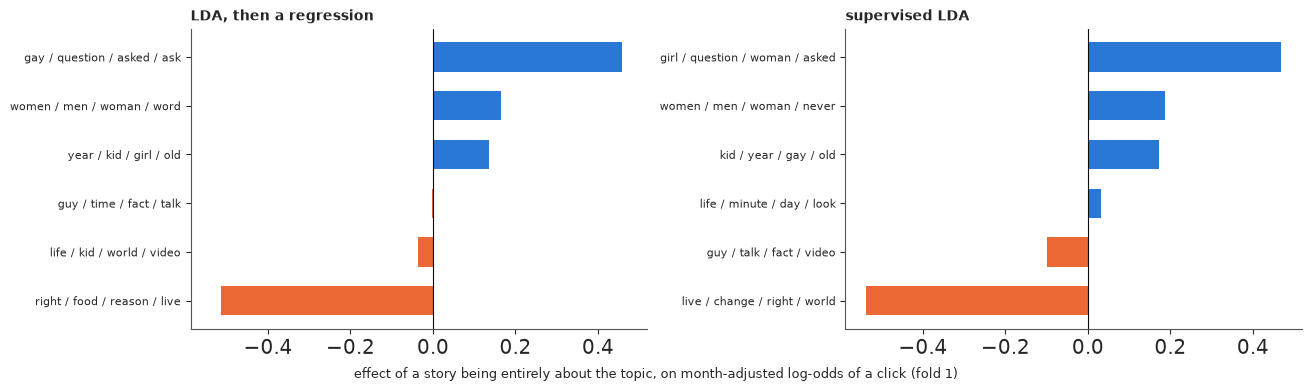

In [11]:
@numba.njit
def _slda_sweeps(doc, word, z, ndk, nkw, nk, nd, y, eta, sigma2, alpha, beta, n_sweeps, seed):
    np.random.seed(seed)
    K, V = nkw.shape
    cum = np.empty(K)
    for _ in range(n_sweeps):
        for i in range(doc.shape[0]):
            d, w, k = doc[i], word[i], z[i]
            ndk[d, k] -= 1; nkw[k, w] -= 1; nk[k] -= 1
            pred = 0.0
            for j in range(K):
                pred += eta[j] * ndk[d, j]
            r = y[d] - pred / nd[d]                       # residual without token i
            total = 0.0
            for j in range(K):
                resid = r - eta[j] / nd[d]
                total += (ndk[d, j] + alpha) * (nkw[j, w] + beta) / (nk[j] + V * beta) * np.exp(-0.5 * resid * resid / sigma2 + 0.5 * r * r / sigma2)
                cum[j] = total
            u = np.random.random() * total
            k = 0
            while cum[k] < u:
                k += 1
            z[i] = k; ndk[d, k] += 1; nkw[k, w] += 1; nk[k] += 1

def slda_gibbs(X, y, K, alpha=0.1, beta=0.05, burn=1000, every=20, draws=20, thin=10, seed=0, lam=1.0):
    g = np.random.default_rng(seed)
    d_i, w_i = np.nonzero(X); n = X[d_i, w_i]; doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    D, V = X.shape
    z = g.integers(K, size=doc.size)
    ndk = np.zeros((D, K), np.int64); nkw = np.zeros((K, V), np.int64)
    np.add.at(ndk, (doc, z), 1); np.add.at(nkw, (z, word), 1); nk = nkw.sum(1); nd = ndk.sum(1).astype(float)
    eta, sigma2 = np.zeros(K), float(np.var(y))
    for it in range(burn // every):
        _slda_sweeps(doc, word, z, ndk, nkw, nk, nd, y, eta, sigma2, alpha, beta, every, seed + it)
        zbar = ndk / nd[:, None]
        eta = np.linalg.solve(zbar.T @ zbar + lam * np.eye(K), zbar.T @ y)   # ridge, as a weak N(0, sigma2/lam) prior
        sigma2 = float(np.mean((y - zbar @ eta) ** 2))
    phis = []
    for s in range(draws):
        _slda_sweeps(doc, word, z, ndk, nkw, nk, nd, y, eta, sigma2, alpha, beta, thin, seed + 10_000 + s)
        phis.append((nkw + beta) / (nk[:, None] + V * beta))
    return np.array(phis), eta, sigma2

def foldin_zbar(X, phis, alpha=0.1, sweeps=50, seed=0):
    d_i, w_i = np.nonzero(X); n = X[d_i, w_i]; doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    K = phis.shape[1]; out = np.zeros((len(X), K))
    for s, ph in enumerate(phis):
        z = np.random.default_rng(seed + s).integers(K, size=doc.size)
        ndk = np.zeros((len(X), K), np.int64); np.add.at(ndk, (doc, z), 1)
        _foldin_sweeps(doc, word, z, ndk, ph, alpha, sweeps, seed + s)
        out += ndk / np.maximum(ndk.sum(1, keepdims=True), 1)
    return out / len(phis)

yc = y_rel - y_rel.mean()
pred_slda, pred_two = np.zeros_like(yc), np.zeros_like(yc)
t0 = time.perf_counter()
for f in range(5):
    tr, te = cv_fold != f, cv_fold == f
    phis_s, eta_s, s2_s = slda_gibbs(X_txt[tr], yc[tr], 6, seed=f)
    pred_slda[te] = foldin_zbar(X_txt[te], phis_s[::4]) @ eta_s
    phis_u, th_u, _ = lda_gibbs(X_txt[tr], 6, burn=1000, draws=20, seed=f)
    zb = th_u.mean(0)
    eta_u = np.linalg.solve(zb.T @ zb + np.eye(6), zb.T @ yc[tr])
    pred_two[te] = foldin_zbar(X_txt[te], phis_u[::4]) @ eta_u
    if f == 0:
        slda_topics, slda_eta, lda_topics, lda_eta = phis_s.mean(0), eta_s, phis_u.mean(0), eta_u
r2 = lambda p: 1 - np.mean((yc - p) ** 2) / np.var(yc)
print(f"5-fold CV, held-out stories ({time.perf_counter() - t0:.0f} s):  supervised LDA R2 = {r2(pred_slda):.3f};  "
      f"LDA then regression R2 = {r2(pred_two):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharex=True)
for ax, eta_, phi_, name in [(axes[0], lda_eta, lda_topics, "LDA, then a regression"),
                             (axes[1], slda_eta, slda_topics, "supervised LDA")]:
    o = np.argsort(eta_)
    ax.barh(range(6), eta_[o], color=[SERIES[0] if v > 0 else SERIES[1] for v in eta_[o]], height=0.6)
    ax.set_yticks(range(6), [" / ".join(vocab[np.argsort(-phi_[k])[:4]]) for k in o], fontsize=8)
    ax.axvline(0, color=INK, lw=0.8)
    ax.set_title(name, fontsize=10, loc="left")
    ax.grid(axis="y", visible=False)
fig.supxlabel("effect of a story being entirely about the topic, on month-adjusted log-odds of a click (fold 1)", fontsize=9);

On held-out stories supervised LDA explains 11.6% of the variance of month-adjusted click-through,
against 8.2% for LDA followed by a regression on the same folds. The topics bend towards what
matters for clicks: in the first fold the most positive topic sharpens from "gay / question /
asked / ask" to "girl / question / woman / asked", and the most negative from "right / food /
reason / live" to "live / change / right / world" (causes and policy), whose effect grows
slightly. The price is that the topics are no longer a neutral description of the corpus - they
are partly defined by the outcome, so "topic k raises clicks" is circular on the training data
and only held-out checks like this one count. (This is also the joint model that E72's discussion
of attenuation pointed to.)

## G. Counts, not bags: Poisson factorisation for baskets

For purchases (and clicks, plays, views), LDA's multinomial fixes each document's length and
asks only which products it contains. **Hierarchical Poisson factorisation** (HPF; Gopalan,
Hofman & Blei 2015) models the counts themselves: customer $u$ has non-negative preferences
$\theta_{uk}$, product $i$ has attributes $\beta_{ik}$, and the number of orders containing it is
$y_{ui} \sim \text{Poisson}(\boldsymbol\theta_u^\top\boldsymbol\beta_i)$, with Gamma priors whose
rates are themselves Gamma (a customer's overall activity, a product's popularity). Zeros are
cheap (they only enter through sums), so it scales to very sparse data, and heavy buyers and
best-sellers are modelled rather than normalised away. Inference here is coordinate-ascent
variational Bayes with the paper's closed-form updates.

The test is E72's: hide half of the products of a random 20% of customers and recommend ten.

In [12]:
def hpf(Y, K, a=0.3, a1=0.3, b1=1.0, c=0.3, c1=0.3, d1=1.0, iters=100, seed=0):
    """Hierarchical Poisson factorisation (Gopalan, Hofman & Blei 2015) by coordinate-ascent VI."""
    g = np.random.default_rng(seed)
    U, I = Y.shape
    u_i, i_i = np.nonzero(Y); y = Y[u_i, i_i].astype(float)
    g_shp = a + g.uniform(0, 0.01, (U, K)); g_rte = a1 / b1 + g.uniform(0, 0.01, (U, K))
    l_shp = c + g.uniform(0, 0.01, (I, K)); l_rte = c1 / d1 + g.uniform(0, 0.01, (I, K))
    k_rte = a1 / b1 + np.zeros(U); k_shp = a1 + K * a
    t_rte = c1 / d1 + np.zeros(I); t_shp = c1 + K * c
    for it in range(iters):
        log_phi = (digamma(g_shp) - np.log(g_rte))[u_i] + (digamma(l_shp) - np.log(l_rte))[i_i]
        phi = np.exp(log_phi - log_phi.max(1, keepdims=True)); phi /= phi.sum(1, keepdims=True)
        yphi = y[:, None] * phi
        g_shp = a + np.zeros((U, K)); np.add.at(g_shp, u_i, yphi)
        g_rte = (k_shp / k_rte)[:, None] + (l_shp / l_rte).sum(0)[None]
        k_rte = a1 / b1 + (g_shp / g_rte).sum(1)
        l_shp = c + np.zeros((I, K)); np.add.at(l_shp, i_i, yphi)
        l_rte = (t_shp / t_rte)[:, None] + (g_shp / g_rte).sum(0)[None]
        t_rte = c1 / d1 + (l_shp / l_rte).sum(1)
    return g_shp / g_rte, l_shp / l_rte

retail = data.load("online_retail")
n_cust = retail.groupby("stock_code")["customer_id"].nunique()
retail = retail[retail["stock_code"].isin(n_cust.index[n_cust >= 30])]
n_prod = retail.groupby("customer_id")["stock_code"].nunique()
retail = retail[retail["customer_id"].isin(n_prod.index[n_prod >= 10])]
cust_i, customers = pd.factorize(retail["customer_id"])
prod_i, products = pd.factorize(retail["stock_code"])
X_ret = np.zeros((len(customers), len(products)), np.int64)
X_ret[cust_i, prod_i] = 1
orders = np.zeros_like(X_ret)
orders[cust_i, prod_i] = retail["n_invoices"].to_numpy()
split_ret = np.random.default_rng(14)                 # the same split as E72
test_ret = split_ret.random(len(X_ret)) < 0.2
shown = np.zeros_like(X_ret[test_ret])
for d, row in enumerate(X_ret[test_ret]):
    bought = np.flatnonzero(row)
    split_ret.shuffle(bought)
    shown[d, bought[: len(bought) // 2]] = 1
hidden = X_ret[test_ret] - shown
print(f"{len(customers):,} customers x {len(products):,} products; {test_ret.sum()} held-out customers")


def hit_rate(score_):
    score_ = np.where(shown > 0, -np.inf, score_)
    top10 = np.argsort(-score_, 1)[:, :10]
    return np.mean(np.take_along_axis(hidden, top10, 1).sum(1) / np.minimum(hidden.sum(1), 10))


X_train = X_ret[~test_ret]
col_norm = np.linalg.norm(X_train, axis=0).clip(1e-9)
item_sim = (X_train / col_norm).T @ (X_train / col_norm)
np.fill_diagonal(item_sim, 0)
hits = {"best-sellers": hit_rate(np.tile(X_train.sum(0), (len(shown), 1)).astype(float)),
        "item-to-item similarity": hit_rate(shown @ item_sim + 1e-9 * X_train.sum(0))}
t0 = time.perf_counter()
phis_ret, _, _ = lda_gibbs(X_train, 40, alpha=0.1, beta=0.05, burn=300, draws=5, thin=20, seed=70)
th_ret = np.zeros(shown.shape)                                  # predicted product probabilities
d_s, w_s = np.nonzero(shown)
for s, ph in enumerate(phis_ret):
    zz = np.random.default_rng(s).integers(40, size=len(d_s))
    nd_ = np.zeros((len(shown), 40), np.int64)
    np.add.at(nd_, (d_s, zz), 1)
    _foldin_sweeps(d_s, w_s, zz, nd_, ph, 0.1, 50, s)
    th_ret += ((nd_ + 0.1) / (nd_.sum(1, keepdims=True) + 4.0)) @ ph / len(phis_ret)
hits["LDA, 40 missions (binary)"] = hit_rate(th_ret)
t_lda = time.perf_counter() - t0
for name, Y in [("HPF, 40 factors (binary)", np.vstack([X_train, shown])),
                ("HPF, 40 factors (order counts)", np.vstack([orders[~test_ret], shown * orders[test_ret]]))]:
    t0 = time.perf_counter()
    th_u, be_i = hpf(Y, 40, seed=40)
    hits[name] = hit_rate(th_u[len(X_train):] @ be_i.T)
    print(f"{name}: {time.perf_counter() - t0:.0f} s")
print(f"LDA: {t_lda:.0f} s")
print(pd.Series(hits, name="hit rate of the top 10").round(3))

3,661 customers x 2,087 products; 750 held-out customers


HPF, 40 factors (binary): 13 s


HPF, 40 factors (order counts): 13 s
LDA: 5 s
best-sellers                      0.109
item-to-item similarity           0.273
LDA, 40 missions (binary)         0.249
HPF, 40 factors (binary)          0.223
HPF, 40 factors (order counts)    0.241
Name: hit rate of the top 10, dtype: float64


Poisson factorisation does not beat the multinomial here. With order counts it recommends about as
well as LDA with 40 missions (hit rate 0.24 against 0.25), with 0/1 data a little worse (0.22),
and neither beats item-to-item similarity (0.27). Its strengths are elsewhere: it models *how
much* each customer buys (a wholesaler with hundreds of orders and an occasional buyer are
different documents, not normalised copies), zeros cost nothing so it scales to millions of
customers, and its Gamma posteriors give a new customer sensibly uncertain preferences. As in E72,
the simple recommender is the baseline to beat.

## H. The scoreboard

Every headline model on the same yardsticks (HDP and supervised LDA are not in it: the HDP has ~40
topics, and supervised LDA's usefulness was scored on held-out stories, a different protocol).

                                 coherence (NPMI)  diversity  stability, worst topic  stability, median topic  click-through CV R2  seconds per fit
model                                                                                                                                              
LDA (collapsed Gibbs), 6 topics             0.081      0.727                   0.053                    0.250                0.105            2.519
DMM (GSDMM), 6 clusters                    -0.021      0.733                   0.053                    0.333                0.097            1.296
Biterm topic model, 6 topics               -0.004      0.713                   0.176                    0.292                0.097            5.746
Anchor words (spectral)                     0.029      0.333                   1.000                    1.000                0.012            0.045
LDA, Gibbs started from anchors             0.083      0.713                   0.111                    0.292   

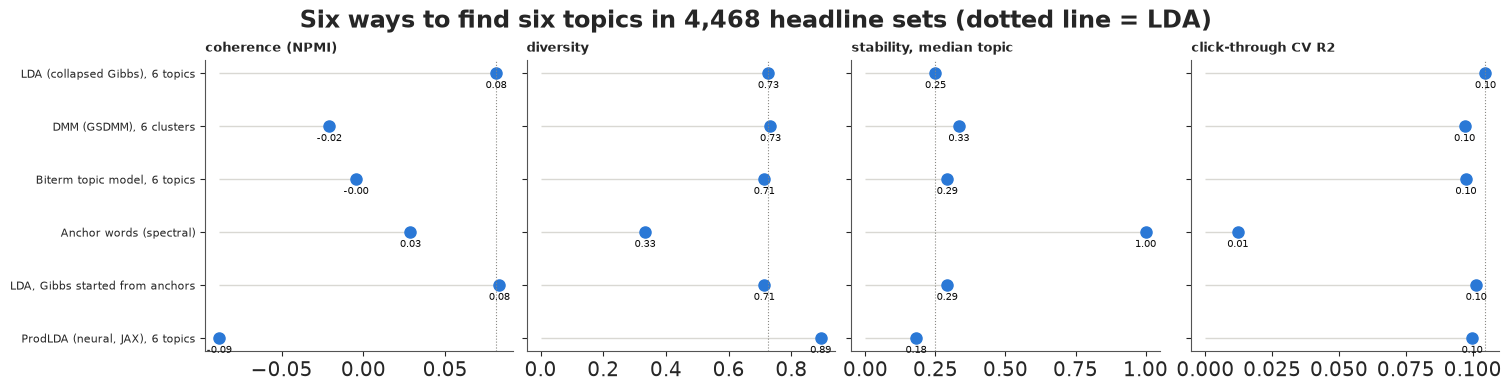

In [13]:
board = pd.DataFrame(scoreboard).set_index("model")
print(board.round(3))

metrics = ["coherence (NPMI)", "diversity", "stability, median topic", "click-through CV R2"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, m in zip(axes, metrics):
    vals = board[m]
    ax.hlines(range(len(board)), vals.min() if vals.min() < 0 else 0, vals, color="#d9d8d3", lw=1)
    ax.plot(vals, range(len(board)), "o", ms=8, color=SERIES[0])
    for y_, v in enumerate(vals):
        ax.text(v, y_ + 0.28, f"{v:.2f}", ha="center", fontsize=7, color=INK)
    ax.set_title(m, fontsize=9, loc="left")
    ax.axvline(board.loc["LDA (collapsed Gibbs), 6 topics", m], color=MUTED, lw=0.8, ls=":")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(board)), board.index, fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Six ways to find six topics in 4,468 headline sets (dotted line = LDA)");

No model dominates. LDA has the best coherence and (with its anchor-started variant) the best
prediction among the unsupervised models, but poor stability. The short-text models and ProdLDA
are not better on the measures that matter most here, except BTM's worst-topic stability and
ProdLDA's diversity. The anchor method is perfectly stable only because it is deterministic (its
"stability" of 1.00 compares a run with itself), and it is the weakest otherwise. All sampled
models predict click-through about equally (R$^2$ about 0.10): the headline text holds a fixed
amount of information about clicks that no *unsupervised* model extracts better - only supervision
(part F) and many more topics (part D) did.

## I. Embeddings and language models

The most recent topic models work in a different space. **BERTopic** (Grootendorst 2022) and
**Top2Vec** (Angelov 2020) embed each document with a pretrained sentence encoder, reduce the
embeddings (UMAP), cluster them (HDBSCAN) and describe each cluster by its distinctive words
(class-based TF-IDF). **Contextualized topic models** (Bianchi et al. 2021) feed such embeddings
to a ProdLDA-style encoder, and the **embedded topic model** (Dieng, Ruiz & Blei 2020) puts words
and topics in one embedding space so that rare words borrow strength from similar ones.
**TopicGPT** (Pham et al. 2024) asks a large language model to propose and assign topics in
natural language. They are not run here because they need pretrained models this project does
not install (say if you want `sentence-transformers` added). What they change:

* **short texts get much easier**: a pretrained encoder knows that "minimum wage" and "paid sick
  leave" are related before seeing any headline - the co-occurrence information the models above
  had to find in 4,468 short documents;
* **most are clustering, not mixed membership**: BERTopic gives a document one topic (like DMM),
  and a cluster count chosen by HDBSCAN's density settings;
* **the uncertainty goes away from view, not from the problem**: UMAP and HDBSCAN are stochastic
  and sensitive to their settings, and an LLM's topics change with the prompt. Every check in
  this notebook and in E72 - stability across restarts, coherence, the purpose-driven choice of
  the number of topics, validation against a downstream outcome - applies unchanged.

## Summary

* **Each post-LDA family targets a real problem, but the problem has to be the one you have.** On
  4,468 short headline sets told in generic words, the short-text models did not beat LDA, the
  anchor method was too data-hungry, and a neural topic model was starved of data.
* **Short texts.** One topic per document (DMM) created a catch-all cluster of half the stories;
  word-pair pooling (BTM) found the sharp stories and was more stable in its worst topic, not more
  coherent.
* **Local modes.** Anchor words give a deterministic answer and a reproducible start; they do not
  make chains agree on topics, and on small corpora the answer itself is poor.
* **How many topics.** Learned priors kept every topic but made a background topic; the HDP settled
  at about 40 topics whatever the truncation - the fit's answer, not a reader's.
* **Neural topic models** gave distinct but incoherent, unstable topics on this small corpus;
  automated coherence and large corpora are where their advantages were reported.
* **Supervision** helped most: supervised LDA predicted held-out click-through better (R$^2$ 0.116
  against 0.082) with topics bent towards the outcome, at the cost of neutrality.
* **Counts.** Poisson factorisation matched LDA at recommending products with order counts, and
  item-to-item similarity stayed ahead.
* **The checks carry over** to every model, including embedding- and LLM-based ones: restarts,
  coherence, purpose-driven size, and a downstream test against a simple baseline.

## Try it yourself

1. **More documents.** Every method here was built for, or tested on, larger corpora. Refit the
   scoreboard on all 22,666 *individual* headlines (one document per arm; shorter still, but five
   times as many). Which models gain most - the anchor method and ProdLDA, which need data, or
   the short-text models?
2. **A sequence model for the web.** E72 found that browsing intents could not beat "more of the
   same" at predicting the rest of a visit. Fit a hidden Markov model (E24) with a few states to
   the msnbc.com sessions, keeping the order of page views, and compare its held-out log score
   with E72's table.
3. **Supervised HDP or supervised ProdLDA.** Add the click-through response to the HDP sampler of
   part D (as in part F) or as a regression head on ProdLDA's encoder. Does letting the number of
   topics grow improve held-out prediction beyond supervised LDA's?